# Generación de recetas de cocina en español con GPT-2

Taller de NLP basado en el notebook guía 1-text-generation.ipynb de la sesión 4 (generación de texto con modelos GPT).

Grupo: Julián Espinosa, Jhon Jairo Cuervo y David Crespo.

## El problema

Una receta tiene una estructura fija: un nombre, una lista de ingredientes y unos pasos. Además, las partes deben ser coherentes entre sí. Los pasos deberían usar los ingredientes de la lista y no deberían aparecer ingredientes que nunca se mencionaron.

Escogimos este caso por dos razones. La primera es que se puede evaluar con números. En la guía la calidad de los chistes se juzga leyéndolos, pero en una receta podemos medir si respeta el formato, cuántos de los ingredientes listados se usan en los pasos y cuántos ingredientes aparecen en los pasos sin estar en la lista. La segunda es que pone a prueba algo difícil para un modelo que genera un token a la vez: para escribir pasos coherentes tiene que tener en cuenta la lista de ingredientes que escribió bastante antes.

El modelo GPT-2 en español que usa la guía sabe escribir en español, pero no sabe cómo es una receta. Lo ajustamos con 4000 recetas reales, comparamos dos formas de hacerlo (ajustar todo el modelo o usar LoRA) y después estudiamos cómo cambia el resultado según la estrategia de decodificación.

## 0. Preparación del entorno

In [ ]:
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Corriendo en Colab: {IN_COLAB}")

Corriendo en Colab: True


In [ ]:
!pip install -q -U transformers datasets accelerate peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 37.7 MB/s eta 0:00:00


In [ ]:
import os
import re
import time
import math
import random
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from transformers import set_seed

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")
print(f"Versión de transformers: {transformers.__version__}")

# Colores fijos por variante, para que cada modelo tenga el mismo color en todas las gráficas
COLORES = {
    'Base (sin ajustar)': '#898781',
    'Fine-tuning completo': '#2a78d6',
    'LoRA': '#eb6834',
    'Recetas reales': '#1baf7a',
}
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.3, 'figure.dpi': 100})

Dispositivo: cuda
Versión de transformers: 5.18.0


Dejamos un modo más liviano para cuando no hay GPU. En el taller 3 vimos que entrenar un modelo de este tamaño en la CPU de Colab es muy lento, así que el tamaño del experimento cambia según el hardware:

- Con GPU: más recetas, recetas más largas, 2 épocas y 30 recetas de prueba para evaluar la generación.
- Sin GPU: menos recetas, recetas más cortas, 1 época y 8 recetas de prueba.

Nosotros lo ejecutamos en Colab con una GPU T4, así que los resultados de este notebook son los de la versión con GPU.

In [ ]:
CON_GPU = DEVICE.type == 'cuda'

CONFIG = {
    'model_name': 'mrm8488/spanish-gpt2',
    'max_len': 384 if CON_GPU else 192,           # tokens máximos por receta (lo justificamos en el EDA)
    'max_train': 4000 if CON_GPU else 400,         # recetas de entrenamiento
    'max_eval': 300 if CON_GPU else 80,            # recetas de validación y de prueba
    'epochs': 2 if CON_GPU else 1,
    'batch_size': 8 if CON_GPU else 4,
    'lr_completo': 5e-5,                           # learning rate para el fine-tuning completo
    'lr_lora': 2e-4,                               # LoRA entrena muy pocos parámetros: necesita un lr mayor
    'lora_r': 16,
    'lora_alpha': 32,
    'n_prompts': 30 if CON_GPU else 8,             # recetas del conjunto de prueba usadas para evaluar la generación
    'max_new_tokens': 300 if CON_GPU else 160,
    'gen_batch_size': 16 if CON_GPU else 8,
}
for k, v in CONFIG.items():
    print(f"{k:>16}: {v}")

      model_name: mrm8488/spanish-gpt2
         max_len: 384
       max_train: 4000
        max_eval: 300
          epochs: 2
      batch_size: 8
     lr_completo: 5e-05
         lr_lora: 0.0002
          lora_r: 16
      lora_alpha: 32
       n_prompts: 30
  max_new_tokens: 300
  gen_batch_size: 16


Sobre el learning rate: en el taller 3 usamos el mismo valor para todas las variantes y eso perjudicó a la que entrenaba pocos parámetros. Aquí usamos 5e-5 para el fine-tuning completo y 2e-4 para LoRA, que es un valor más común para esa técnica porque solo se entrenan unas matrices pequeñas que empiezan desde cero.

## 1. El dataset

Usamos el dataset somosnlp/RecetasDeLaAbuela de Hugging Face, con recetas en español recolectadas de páginas web de cocina. Cada receta tiene, entre otros campos, nombre, ingredientes, pasos, país, categoría, duración y número de comensales.

In [ ]:
from datasets import load_dataset

DATASET_NAME = 'somosnlp/RecetasDeLaAbuela'
try:
    raw_dataset = load_dataset(DATASET_NAME, 'version_1', split='train')
except Exception as e:
    print(f"No se pudo cargar la configuración 'version_1' ({e}); cargando la configuración por defecto")
    raw_dataset = load_dataset(DATASET_NAME, split='train')

raw = raw_dataset.to_pandas()
print(f"Recetas: {len(raw)} | Columnas: {list(raw.columns)}")
raw.head(3)

README.md:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

main.csv: reconstructing file:   0%|          |  0.00B / 40.3MB            

main.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/20236 [00:00<?, ? examples/s]

Recetas: 20236 | Columnas: ['Id', 'Nombre', 'URL', 'Ingredientes', 'Pasos', 'Pais', 'Duracion', 'Categoria', 'Contexto', 'Valoracion y Votos', 'Comensales', 'Tiempo', 'Dificultad', 'Valor nutricional']


,Id,Nombre,URL,Ingredientes,Pasos,Pais,Duracion,Categoria,Contexto,Valoracion y Votos,Comensales,Tiempo,Dificultad,Valor nutricional
0,1,Tacos Dorados de Papa,https://www.mexicoenmicocina.com/tacos-dorados...,"½ taza de cilantro finamente picado, 1 taza de...",Pon las papas enteras en una olla mediana y cú...,MEX,01:00,vegetarianos,None,None,6,None,None,"Alto en calorías, Alto en grasas, Alto en sodio"
1,2,Ensalada de Chayotes,https://www.mexicoenmicocina.com/receta-ensala...,"½ cucharadita sal, ¼ cucharadita de pimienta r...",Coloca los chayotes en una cacerola y cúbralos...,MEX,00:25,vegetarianos,None,None,4,None,None,"Bajo en calorías, Sin grasa, Alto en fibra"
2,3,Huevos a la Mexicana,https://www.mexicoenmicocina.com/huevos-a-la-m...,"½ Chile Serrano cortado en pequeños trocitos*,...",Calienta el aceite en una sartén mediana a fue...,MEX,00:15,vegetarianos,None,None,1,None,None,"Alto en calorías, Alto en grasas, Alto en sodio"


In [ ]:
ejemplo = raw.iloc[0]
print('NOMBRE:', ejemplo['Nombre'])
print('\nINGREDIENTES (texto original):\n', ejemplo['Ingredientes'][:400])
print('\nPASOS (texto original):\n', ejemplo['Pasos'][:600])

NOMBRE: Tacos Dorados de Papa

INGREDIENTES (texto original):
 ½ taza de cilantro finamente picado, 1 taza de tomate picadito y sin semillas, 1 cucharada de jugo de limón, 12 to rtillas de maíz, ⅔ de taza de aceite vegetal para freír los taquitos, 2 chiles serranos en cubitos, Sal al gusto, 2 tazas de repollo en tiras finas, ½ taza de crema mexicana, Salsa roja, ½ taza de cebolla blanca en cubitos, 3 papas rojas de tamaño mediano ~510 gr. *, 24 palillos de ma

PASOS (texto original):
 Pon las papas enteras en una olla mediana y cúbrelas con agua fría. NO peles ni cortes las papas. No queremos que las papas absorban demasiada agua, porque luego esa agua se liberará formando burbujas al freírlas y el aceite salpicará. Pon el fuego a medio alto y cocínalas hasta que estén tiernas (unos 20 a 25 minutos). Escurre las papas para quitar el excedente de agua y pásalas a un tazón. Espera hasta que estén lo suficientemente frías para que puedas tocarlas y quita las cáscaras.Sazona las papas con 

Antes de entrenar hay que limpiar dos cosas del formato original:

- Los ingredientes vienen en un solo texto separado por comas. Algunos ingredientes tienen comas internas ("Queso Fresco mexicano, cortado en cubitos"), así que si después de una coma el texto empieza en minúscula lo unimos con el ingrediente anterior.
- En los pasos a veces falta el espacio después del punto ("quita las cáscaras.Sazona las papas"). Lo agregamos.

## 2. Análisis exploratorio (EDA)

### Valores faltantes

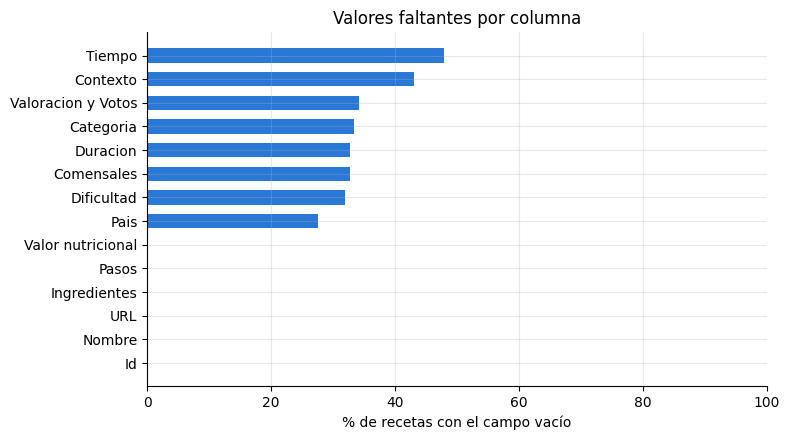

Id                     0.0
Nombre                 0.0
URL                    0.0
Ingredientes           0.0
Pasos                  0.0
Valor nutricional      0.0
Pais                  27.6
Dificultad            31.9
Comensales            32.7
Duracion              32.8
Categoria             33.3
Valoracion y Votos    34.2
Contexto              43.1
Tiempo                47.8


In [ ]:
faltantes = raw.isna().mean().sort_values() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(faltantes.index, faltantes.values, color='#2a78d6', height=0.6)
ax.set_xlabel('% de recetas con el campo vacío')
ax.set_title('Valores faltantes por columna')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()
print(faltantes.round(1).to_string())

In [ ]:
def limpiar_texto(s):
    s = str(s)
    s = re.sub(r'\.(?=[A-ZÁÉÍÓÚÑ¿¡])', '. ', s)   # punto pegado a la siguiente oración
    s = re.sub(r'\s+', ' ', s)
    return s.strip()


def separar_ingredientes(s):
    partes = [p.strip() for p in str(s).split(',')]
    ingredientes = []
    for p in partes:
        if not p:
            continue
        if ingredientes and p[0].islower():
            ingredientes[-1] += ', ' + p      # continuación del ingrediente anterior
        else:
            ingredientes.append(p)
    return ingredientes


def duracion_a_minutos(s):
    m = re.match(r'^\s*(\d{1,2}):(\d{2})\s*$', str(s))
    return int(m.group(1)) * 60 + int(m.group(2)) if m else np.nan


df = raw.dropna(subset=['Nombre', 'Ingredientes', 'Pasos']).copy()
df['Nombre'] = df['Nombre'].map(limpiar_texto)
df['ingredientes_lista'] = df['Ingredientes'].map(separar_ingredientes)
df['pasos'] = df['Pasos'].map(limpiar_texto)
df['n_ingredientes'] = df['ingredientes_lista'].map(len)
df['palabras_pasos'] = df['pasos'].str.split().map(len)
df['minutos'] = df['Duracion'].map(duracion_a_minutos)

# Quitamos recetas degeneradas: sin lista de ingredientes real o con pasos de una línea
antes = len(df)
df = df[(df['n_ingredientes'] >= 2) & (df['palabras_pasos'] >= 10)].reset_index(drop=True)
print(f"Recetas con nombre, ingredientes y pasos: {antes} | tras quitar recetas degeneradas: {len(df)}")

nombres_norm = df['Nombre'].str.lower().str.strip()
print(f"Nombres de receta repetidos: {nombres_norm.duplicated().sum()} "
      f"(p. ej. {nombres_norm.value_counts().head(3).to_dict()})")

Recetas con nombre, ingredientes y pasos: 20236 | tras quitar recetas degeneradas: 20196
Nombres de receta repetidos: 367 (p. ej. {'arroz con pollo': 13, 'lomo saltado': 9, 'crema de verduras': 6})


### País de origen y categoría

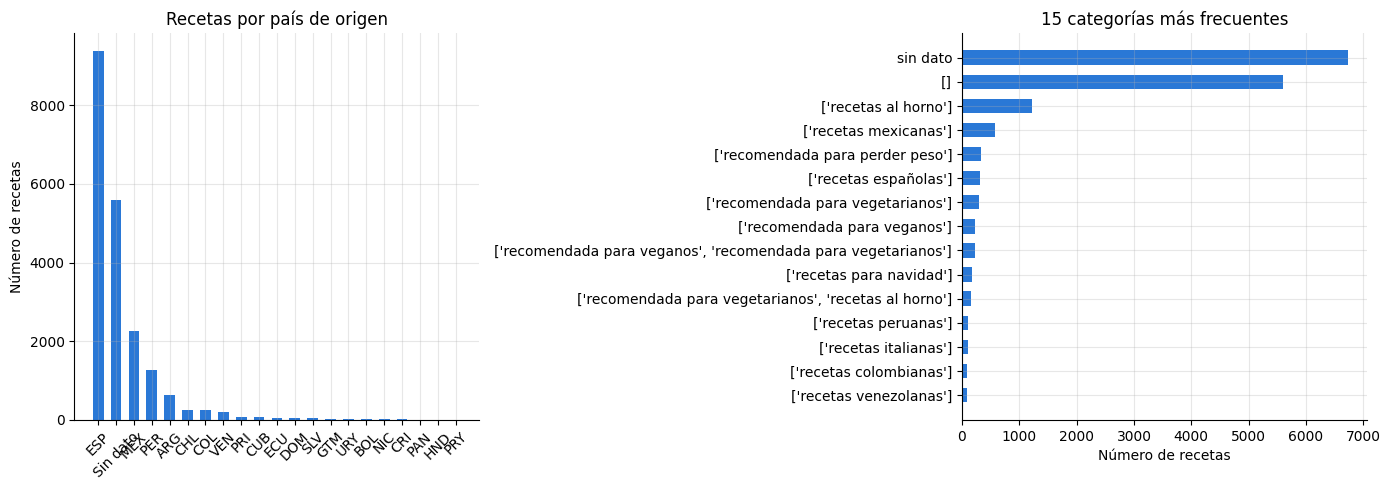

Categorías distintas: 722
Pais
ESP         46.4
Sin dato    27.6
MEX         11.1
PER          6.3
ARG          3.1
CHL          1.2
COL          1.2
VEN          1.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

paises = df['Pais'].fillna('Sin dato').value_counts()
axes[0].bar(paises.index, paises.values, color='#2a78d6', width=0.6)
axes[0].set_title('Recetas por país de origen')
axes[0].set_ylabel('Número de recetas')
axes[0].tick_params(axis='x', rotation=45)

categorias = df['Categoria'].fillna('Sin dato').str.lower().value_counts().head(15)[::-1]
axes[1].barh(categorias.index, categorias.values, color='#2a78d6', height=0.6)
axes[1].set_title('15 categorías más frecuentes')
axes[1].set_xlabel('Número de recetas')

plt.tight_layout()
plt.show()
print(f"Categorías distintas: {df['Categoria'].nunique()}")
print((paises / paises.sum() * 100).round(1).head(8).to_string())

### Tamaño de las recetas

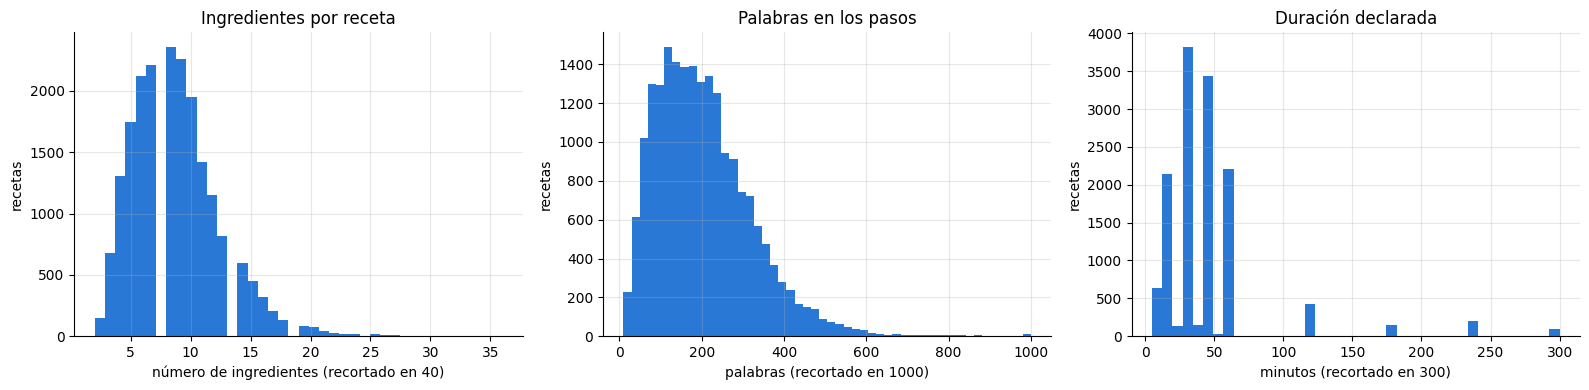

       n_ingredientes  palabras_pasos  minutos
count         20196.0         20196.0  13438.0
mean              8.7           205.0     45.8
std               3.7           118.6     46.9
min               2.0            10.0      5.0
25%               6.0           116.0     30.0
50%               8.0           188.0     30.0
75%              11.0           271.0     45.0
max              36.0          1819.0    480.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['n_ingredientes'].clip(upper=40), bins=40, color='#2a78d6')
axes[0].set_title('Ingredientes por receta')
axes[0].set_xlabel('número de ingredientes (recortado en 40)')

axes[1].hist(df['palabras_pasos'].clip(upper=1000), bins=50, color='#2a78d6')
axes[1].set_title('Palabras en los pasos')
axes[1].set_xlabel('palabras (recortado en 1000)')

axes[2].hist(df['minutos'].dropna().clip(upper=300), bins=40, color='#2a78d6')
axes[2].set_title('Duración declarada')
axes[2].set_xlabel('minutos (recortado en 300)')

for ax in axes:
    ax.set_ylabel('recetas')
plt.tight_layout()
plt.show()

print(df[['n_ingredientes', 'palabras_pasos', 'minutos']].describe().round(1))

### Léxico de ingredientes

Para medir la coherencia entre ingredientes y pasos necesitamos saber qué palabras son ingredientes. Armamos un léxico con los mismos datos: tomamos las palabras de las listas de ingredientes, quitamos palabras comunes, unidades de medida (taza, cucharada, gramos) y descriptores (picado, grande, fresco), unificamos plurales y tildes, y dejamos las palabras que aparecen en al menos 20 recetas.

No es perfecto. Se cuelan algunas palabras que no son ingredientes, como "sopera" (de "cucharada sopera") o "mililitro", y los ingredientes de varias palabras se cuentan por separado. Pero sirve para comparar los modelos entre sí y con las recetas reales.

Palabras en el léxico de ingredientes: 972


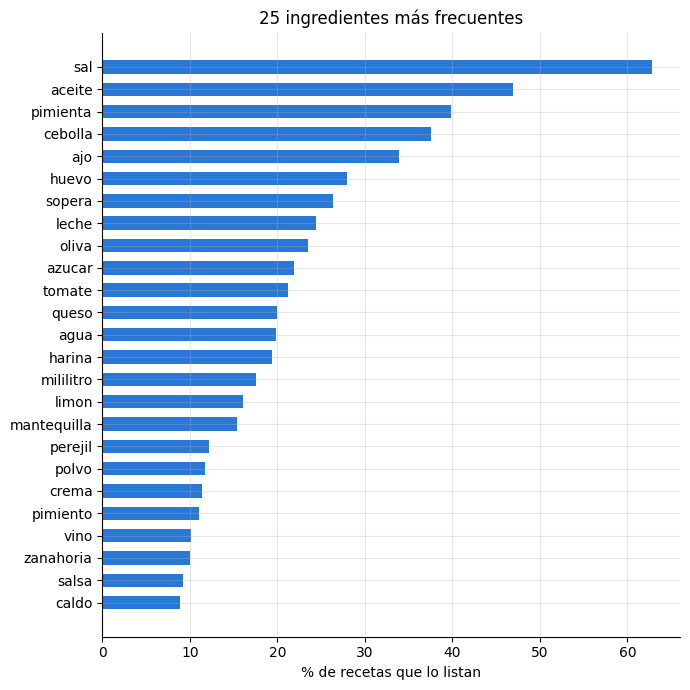

In [ ]:
NO_INGREDIENTES = set('''
de del la las el los y o a al en con sin para por su sus un una unos unas que se lo le mas muy bien cada
taza tazas cucharada cucharadas cucharadita cucharaditas cda cdas cdta cdtas gramos gramo gr grs kg kilo kilos
kilogramo kilogramos mililitros litro litros onza onzas libra libras pizca pizcas pieza piezas pza pzas
rebanada rebanadas rodaja rodajas trozo trozos lata latas paquete paquetes sobre sobres manojo ramita ramitas
diente dientes chorrito chorro puñado punado vaso vasos copa copas unidad unidades porcion porciones bolsa
gusto opcional aproximadamente cantidad necesaria suficiente necesario
picado picada picados picadas finamente fino fina finas finos cortado cortada cortados cortadas cubo cubos
cubito cubitos tira tiras rallado rallada rallados ralladas molido molida molidos molidas fresco fresca frescos
frescas grande grandes mediano mediana medianos medianas pequeno pequena pequenos pequenas entero entera enteros
enteras cocido cocida cocidos cocidas pelado pelada pelados peladas semilla semillas desmenuzado desmenuzada
rebanado rebanados derretido derretida suave suaves blanco blanca blancos blancas rojo roja rojos rojas verde
verdes negro negra amarillo amarilla natural tamano temperatura ambiente tiempo extra virgen recien partido
partida partidos mitad mitades medio media cuarto tercio menos uno dos tres cuatro cinco seis siete ocho nueve
diez servir decorar decoracion freir tipo marca preferencia frio fria caliente tibia tibio limpio limpia
lavado lavada hoja hojas mas otra otro otros otras picadito picadita picaditos mexicano mexicana
espanol espanola
'''.split())


def sin_tildes(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')


def palabras(texto):
    return re.findall(r'[a-zñ]+', sin_tildes(texto.lower()))


# Vocabulario de todo el corpus (ingredientes y pasos), para decidir cómo unificar plurales
VOCAB = Counter()
for lista, pasos in zip(df['ingredientes_lista'], df['pasos']):
    VOCAB.update(palabras(' '.join(lista) + ' ' + pasos))


def singular(w):
    # "tomates" -> "tomate", "limones" -> "limon", "papas" -> "papa": se elige la forma que existe en el corpus
    if len(w) > 3 and w.endswith('s'):
        for candidata in (w[:-1], w[:-2]):
            if VOCAB.get(candidata, 0) >= 3:
                return candidata
    return w


# Frecuencia de documento: en cuántas recetas aparece cada ingrediente (ya en singular)
frecuencia_norm = Counter()
for lista in df['ingredientes_lista']:
    frecuencia_norm.update({singular(w) for w in palabras(' '.join(lista)) if len(w) >= 3})
for w in list(frecuencia_norm):
    if w in NO_INGREDIENTES or singular(w) in NO_INGREDIENTES:
        del frecuencia_norm[w]

LEXICO = {w for w, c in frecuencia_norm.items() if c >= 20}
print(f"Palabras en el léxico de ingredientes: {len(LEXICO)}")

top = frecuencia_norm.most_common(25)[::-1]
fig, ax = plt.subplots(figsize=(7, 7))
ax.barh([w for w, _ in top], [c / len(df) * 100 for _, c in top], color='#2a78d6', height=0.6)
ax.set_xlabel('% de recetas que lo listan')
ax.set_title('25 ingredientes más frecuentes')
plt.tight_layout()
plt.show()

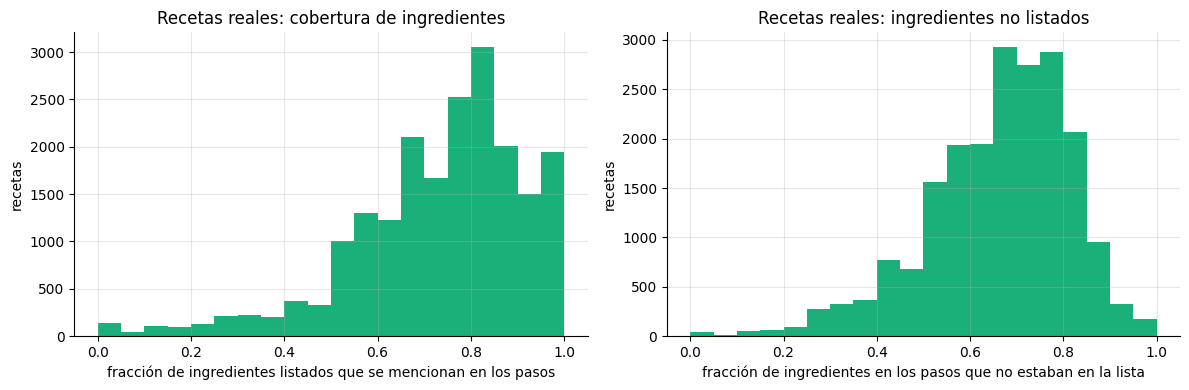

Cobertura media en recetas reales:   0.731
Alucinación media en recetas reales: 0.660


In [ ]:
def ingredientes_en(texto):
    # Conjunto de palabras del léxico que aparecen en un texto
    return {singular(w) for w in palabras(texto)} & LEXICO


df['ing_listados'] = df['ingredientes_lista'].map(lambda l: ingredientes_en(' '.join(l)))
df['ing_en_pasos'] = df['pasos'].map(ingredientes_en)

def cobertura(listados, en_pasos):
    return len(listados & en_pasos) / len(listados) if listados else np.nan

def alucinacion(listados, en_pasos):
    return len(en_pasos - listados) / len(en_pasos) if en_pasos else np.nan

df['cobertura'] = [cobertura(a, b) for a, b in zip(df['ing_listados'], df['ing_en_pasos'])]
df['alucinacion'] = [alucinacion(a, b) for a, b in zip(df['ing_listados'], df['ing_en_pasos'])]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['cobertura'].dropna(), bins=20, color='#1baf7a')
axes[0].set_title('Recetas reales: cobertura de ingredientes')
axes[0].set_xlabel('fracción de ingredientes listados que se mencionan en los pasos')
axes[1].hist(df['alucinacion'].dropna(), bins=20, color='#1baf7a')
axes[1].set_title('Recetas reales: ingredientes no listados')
axes[1].set_xlabel('fracción de ingredientes en los pasos que no estaban en la lista')
for ax in axes:
    ax.set_ylabel('recetas')
plt.tight_layout()
plt.show()

print(f"Cobertura media en recetas reales:   {df['cobertura'].mean():.3f}")
print(f"Alucinación media en recetas reales: {df['alucinacion'].mean():.3f}")

Estas dos distribuciones sirven de referencia. Las recetas reales tampoco tienen cobertura de 1, porque es normal escribir "sazona" en lugar de nombrar la sal y la pimienta, ni cero ingredientes no listados, porque es normal mencionar el agua o el aceite sin ponerlos en la lista. Por eso al evaluar los modelos no buscamos valores perfectos sino valores parecidos a los de las recetas reales.

El valor de ingredientes no listados en las recetas reales (0,66) es alto. Creemos que parte se debe al léxico, que incluye palabras como "salsa" o "caldo" que en los pasos muchas veces se refieren a lo que se está preparando y no a un ingrediente.

### Análisis del EDA

- Hay 20.236 recetas. Quitamos 40 que tenían menos de 2 ingredientes o pasos muy cortos y quedaron 20.196.
- Nombre, ingredientes y pasos están completos. Otros campos como tiempo (48 % vacío), contexto (43 %) o categoría (33 %) tienen muchos vacíos, pero no los usamos para entrenar.
- El dataset es sobre todo español: 46 % de las recetas son de España, 11 % de México, 6 % de Perú y solo 1,2 % de Colombia. Un 28 % no tiene país. Esto importa para el demo, donde probamos platos colombianos.
- Una receta típica tiene 8 ingredientes y unas 190 palabras en los pasos, y la duración más común es 30 minutos.
- Los ingredientes más frecuentes son sal (63 % de las recetas), aceite (47 %), pimienta (40 %), cebolla (38 %) y ajo (34 %).
- Hay 367 nombres repetidos. Por ejemplo, "arroz con pollo" aparece 13 veces.

Un problema que encontramos: en la gráfica de categorías aparecen valores como "['recetas al horno']" o "[]". Una parte del dataset guarda las listas como texto con corchetes y comillas, y lo mismo pasa con los ingredientes y los pasos de esas recetas. Nuestra limpieza separa por comas pero no quita esos corchetes, así que esas recetas entraron al entrenamiento con ese formato. Nos dimos cuenta al leer las recetas generadas y lo comentamos en la sección 8.

## 3. Tokenizador y formato de entrenamiento

El modelo solo ve una secuencia de tokens, así que la estructura de la receta tiene que estar escrita en el texto. Usamos un formato fijo con las marcas "Receta:", "Ingredientes:" y "Pasos:", y al final de cada receta agregamos el token de fin de texto para que el modelo aprenda cuándo parar.

Con este formato podemos controlar la generación. Si le damos al modelo "Receta: Arepas de queso" seguido de "Ingredientes:", lo esperado es que continúe con la lista de ingredientes.

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
EOS_ID = tokenizer.eos_token_id
PAD_ID = tokenizer.pad_token_id
print(f"Tamaño del vocabulario: {len(tokenizer)} | EOS: {tokenizer.eos_token!r} (id {EOS_ID}) | PAD id: {PAD_ID}")


def formatear_receta(nombre, ingredientes, pasos):
    lineas = '\n'.join(f'- {i}' for i in ingredientes)
    return f"Receta: {nombre}\nIngredientes:\n{lineas}\nPasos:\n{pasos}"


def prompt_receta(nombre):
    return f"Receta: {nombre}\nIngredientes:\n"


df['texto'] = [formatear_receta(n, i, p) for n, i, p in zip(df['Nombre'], df['ingredientes_lista'], df['pasos'])]
print(df['texto'].iloc[1][:700])

config.json:   0%|          | 0.00/883 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/226 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/846k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/505k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.45M [00:00<?, ?B/s]

Tamaño del vocabulario: 50266 | EOS: '<|endoftext|>' (id 50265) | PAD id: 50265
Receta: Ensalada de Chayotes
Ingredientes:
- ½ cucharadita sal
- ¼ cucharadita de pimienta recién molida
- ¼ de cebolla blanca o roja cortada en rodajas finas o picada
- 1 cucharada de vinagre suave
- 1 cucharada de agua
- ½ taza de Queso Fresco mexicano, cortado en cubitos
- 2 chayotes grandes
- 1 cucharadita de orégano Mexicano
- 2 cucharadas de aceite de oliva
Pasos:
Coloca los chayotes en una cacerola y cúbralos con agua; cocina a fuego medio-alto hasta que estén suaves, revisa con un cuchillo chuzándolos para ver si están blandos. Este proceso tomará cerca de 15 a 20 minutos dependiendo del tamaño de los chayotes y de cuan tiernos sean. Por lo general, los chayotes más grandes tardan má


In [ ]:
texto_ejemplo = df['texto'].iloc[1][:120]
ids = tokenizer(texto_ejemplo)['input_ids']
print(texto_ejemplo)
print(tokenizer.convert_ids_to_tokens(ids)[:40])

Receta: Ensalada de Chayotes
Ingredientes:
- ½ cucharadita sal
- ¼ cucharadita de pimienta recién molida
- ¼ de cebolla 
['Rece', 'ta', ':', 'ĠEn', 'sal', 'ada', 'Ġde', 'ĠCh', 'ayo', 'tes', 'Ċ', 'In', 'gre', 'dientes', ':', 'Ċ', '-', 'ĠÂ', '½', 'Ġcuchar', 'ad', 'ita', 'Ġsal', 'Ċ', '-', 'ĠÂ', '¼', 'Ġcuchar', 'ad', 'ita', 'Ġde', 'Ġpimienta', 'ĠreciÃ©n', 'Ġmol', 'ida', 'Ċ', '-', 'ĠÂ', '¼', 'Ġde']


### Longitud de las recetas en tokens

La longitud máxima de secuencia es lo que más pesa en el costo del entrenamiento, así que medimos cuántos tokens tiene cada receta con el formato anterior.

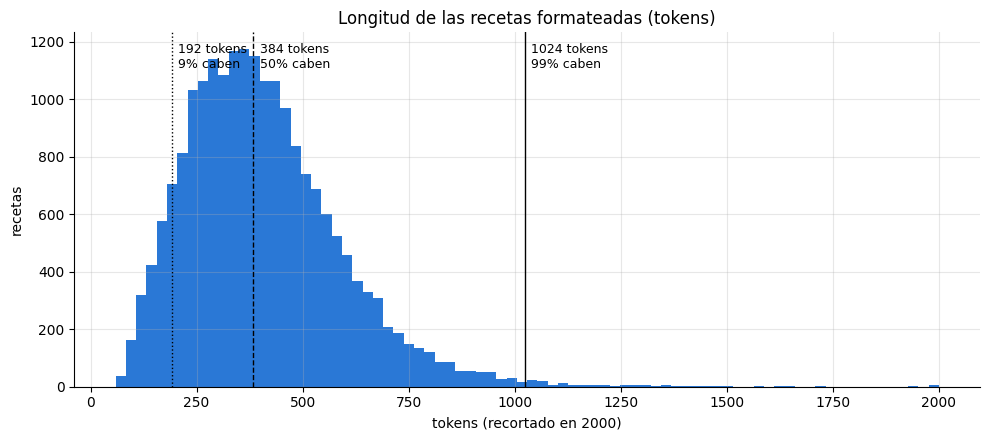

count    20196.0
mean       408.0
std        188.0
min         59.0
25%        276.0
50%        383.0
75%        508.0
max       3734.0
Name: n_tokens, dtype: float64
Recetas que caben en max_len=384: 10168


In [ ]:
longitudes = [len(x) + 1 for x in tokenizer(df['texto'].tolist())['input_ids']]
df['n_tokens'] = longitudes

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(np.clip(df['n_tokens'], 0, 2000), bins=80, color='#2a78d6')
for limite, estilo in [(192, ':'), (384, '--'), (1024, '-')]:
    pct = (df['n_tokens'] <= limite).mean() * 100
    ax.axvline(limite, color='black', linestyle=estilo, linewidth=1)
    ax.text(limite + 15, ax.get_ylim()[1] * 0.9, f'{limite} tokens\n{pct:.0f}% caben', fontsize=9)
ax.set_title('Longitud de las recetas formateadas (tokens)')
ax.set_xlabel('tokens (recortado en 2000)')
ax.set_ylabel('recetas')
plt.tight_layout()
plt.show()

print(df['n_tokens'].describe().round(0))
print(f"Recetas que caben en max_len={CONFIG['max_len']}: {(df['n_tokens'] <= CONFIG['max_len']).sum()}")

La mediana es de 383 tokens y el promedio de 408. GPT-2 acepta hasta 1024, pero entrenar con secuencias largas es más costoso. Con 384 tokens cabe la mitad de las recetas (10.168).

En lugar de cortar las recetas largas, que haría que el modelo viera recetas sin final y no aprendiera a terminar, usamos solo las recetas que caben completas. El modelo aprende sobre todo con recetas cortas y sencillas.

## 4. Preparando los splits

Antes de dividir los datos quitamos los nombres repetidos. Si la misma receta quedara en entrenamiento y en prueba, la perplejidad saldría mejor de lo que es y, al generar con nombres de prueba, el modelo podría estar copiando una receta que ya vio. Quedaron 9.961 recetas únicas que caben en 384 tokens. Usamos 4000 para entrenar, 300 para validación y 300 para prueba.

In [ ]:
pool = df.assign(nombre_norm=df['Nombre'].str.lower().str.strip())
pool = pool.drop_duplicates(subset='nombre_norm')
pool = pool[pool['n_tokens'] <= CONFIG['max_len']]
pool = pool.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Recetas únicas que caben en {CONFIG['max_len']} tokens: {len(pool)}")

n_eval = CONFIG['max_eval']
test_df = pool.iloc[:n_eval]
val_df = pool.iloc[n_eval:2 * n_eval]
train_df = pool.iloc[2 * n_eval:2 * n_eval + CONFIG['max_train']]
print(f"Entrenamiento: {len(train_df)} | Validación: {len(val_df)} | Prueba: {len(test_df)}")
if len(train_df) < CONFIG['max_train']:
    print("Aviso: hay menos recetas disponibles que las pedidas en CONFIG['max_train']")

Recetas únicas que caben en 384 tokens: 9961
Entrenamiento: 4000 | Validación: 300 | Prueba: 300


In [ ]:
from datasets import Dataset, DatasetDict

def tokenizar(batch):
    ids = tokenizer(batch['texto'], truncation=True, max_length=CONFIG['max_len'] - 1)['input_ids']
    return {'input_ids': [x + [EOS_ID] for x in ids]}

splits = DatasetDict({
    'train': Dataset.from_pandas(train_df[['texto']], preserve_index=False),
    'val': Dataset.from_pandas(val_df[['texto']], preserve_index=False),
    'test': Dataset.from_pandas(test_df[['texto']], preserve_index=False),
})
tokenized = splits.map(tokenizar, batched=True, remove_columns=['texto'])
tokenized

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids'],
        num_rows: 4000
    })
    val: Dataset({
        features: ['input_ids'],
        num_rows: 300
    })
    test: Dataset({
        features: ['input_ids'],
        num_rows: 300
    })
})

### El token de fin y el padding

GPT-2 no tiene token de relleno, así que, igual que en la guía, usamos el token de fin como relleno. El problema es que el collator que usa la guía ignora en la pérdida todas las posiciones con ese token, incluida la del final de la receta, y entonces el modelo nunca aprende a terminar. Por eso escribimos un collator propio que solo ignora el relleno, usando la máscara de atención. En la salida se ve que el último token de la receta es el de fin y que su etiqueta se conserva.

In [ ]:
def collate_recetas(batch):
    largo = max(len(x['input_ids']) for x in batch)
    input_ids = torch.full((len(batch), largo), PAD_ID, dtype=torch.long)
    attention_mask = torch.zeros((len(batch), largo), dtype=torch.long)
    for i, x in enumerate(batch):
        n = len(x['input_ids'])
        input_ids[i, :n] = torch.tensor(x['input_ids'])
        attention_mask[i, :n] = 1
    labels = input_ids.clone()
    labels[attention_mask == 0] = -100      # solo se ignora el relleno, no el token de fin de la receta
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

lote = collate_recetas([tokenized['train'][0], tokenized['train'][1]])
print({k: v.shape for k, v in lote.items()})
print("Último token real de la receta 0:", tokenizer.decode(lote['input_ids'][0][lote['attention_mask'][0].sum() - 1]),
      "| su label:", lote['labels'][0][lote['attention_mask'][0].sum() - 1].item())

{'input_ids': torch.Size([2, 288]), 'attention_mask': torch.Size([2, 288]), 'labels': torch.Size([2, 288])}
Último token real de la receta 0: <|endoftext|> | su label: 50265


## 5. Entrenamiento y evaluación

Para comparar modelos usamos la perplejidad, que es la exponencial de la pérdida promedio por token en datos que el modelo no vio. Se puede leer como entre cuántos tokens está dudando el modelo, en promedio, en cada paso. Mientras más baja, mejor.

In [ ]:
import inspect
from transformers import AutoModelForCausalLM, Trainer, TrainingArguments


def cargar_modelo():
    model = AutoModelForCausalLM.from_pretrained(CONFIG['model_name'])
    if model.get_input_embeddings().weight.shape[0] != len(tokenizer):
        # el tokenizador de este checkpoint tiene más tokens que la matriz de embeddings
        model.resize_token_embeddings(len(tokenizer))
    model.config.pad_token_id = PAD_ID
    if getattr(model, 'generation_config', None) is not None:
        model.generation_config.pad_token_id = PAD_ID
    return model.to(DEVICE)


def construir_args(output_dir, learning_rate):
    kwargs = dict(
        output_dir=output_dir,
        num_train_epochs=CONFIG['epochs'],
        learning_rate=learning_rate,
        per_device_train_batch_size=CONFIG['batch_size'],
        per_device_eval_batch_size=CONFIG['batch_size'],
        weight_decay=0.01,
        logging_steps=10 if not CON_GPU else 25,
        save_strategy='no',
        report_to='none',
        fp16=CON_GPU,
        remove_unused_columns=False,
        seed=SEED,
    )
    # Entre versiones de transformers cambió el nombre de este parámetro
    if 'eval_strategy' in inspect.signature(TrainingArguments.__init__).parameters:
        kwargs['eval_strategy'] = 'epoch'
    else:
        kwargs['evaluation_strategy'] = 'epoch'
    return TrainingArguments(**kwargs)


def contar_parametros(model):
    total = sum(p.numel() for p in model.parameters())
    entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, entrenables


def perplejidad(trainer, dataset):
    perdida = trainer.evaluate(dataset)['eval_loss']
    return math.exp(perdida), perdida

### El modelo base sin ajustar

Primero medimos la perplejidad del modelo preentrenado sobre las recetas de prueba y le pedimos dos recetas sin haberlo ajustado.

In [ ]:
modelo_base = cargar_modelo()
total, _ = contar_parametros(modelo_base)
print(f"Parámetros del modelo: {total:,}")

trainer_base = Trainer(model=modelo_base, args=construir_args('./gpt-base', 1e-5),
                       eval_dataset=tokenized['val'], data_collator=collate_recetas)
ppl_base, _ = perplejidad(trainer_base, tokenized['test'])
print(f"Perplejidad del modelo base en el conjunto de prueba: {ppl_base:.2f}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  510MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Parámetros del modelo: 124,446,720


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Training Loss,Validation Loss,Epoch
No log,3.896502,0


Perplejidad del modelo base en el conjunto de prueba: 49.23


In [ ]:
def generar(model, prompts, max_new_tokens=None, batch_size=None, **params):
    # Genera continuaciones para una lista de prompts. Devuelve texto completo (prompt + generado)
    # y si el modelo cerró la receta con el token de fin antes de llegar al límite.
    max_new_tokens = max_new_tokens or CONFIG['max_new_tokens']
    batch_size = batch_size or CONFIG['gen_batch_size']
    model.eval()
    tokenizer.padding_side = 'left'          # en generación el relleno va a la izquierda
    textos, terminados = [], []
    for i in range(0, len(prompts), batch_size):
        lote = prompts[i:i + batch_size]
        enc = tokenizer(lote, return_tensors='pt', padding=True).to(DEVICE)
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=max_new_tokens, pad_token_id=PAD_ID,
                                 eos_token_id=EOS_ID, **params)
        nuevos = out[:, enc['input_ids'].shape[1]:]
        for p, fila in zip(lote, nuevos):
            textos.append(p + tokenizer.decode(fila, skip_special_tokens=True))
            terminados.append(bool((fila == EOS_ID).any()))
    tokenizer.padding_side = 'right'
    return textos, terminados


set_seed(SEED)
nombres_demo = ['Arroz con pollo', 'Galletas de avena']
salidas, _ = generar(modelo_base, [prompt_receta(n) for n in nombres_demo], max_new_tokens=120,
                     do_sample=True, top_p=0.9, top_k=0)
for s in salidas:
    print(s)
    print('-' * 80)

Receta: Arroz con pollo
Ingredientes:
Untar con pollo grano USE fumar hierba: hacer llenar el carro, cortar paco, cocer: salar y secar se obtiene hirviendo fuego en su presencia.levaduras, enfermedades que pueden ser causadas por levaduras, hongos nocivos u hongos de otras fuentes, esto ocasiona enfermedad celulítica); levaduras, vino: Plato o bien melaza; micohalo, hongos, adiposo, consenado y fermentación) y que utilice como guía para realizar todo el trabajo.comensales: comensales nuestro exprés: agua (por vaso), leche
--------------------------------------------------------------------------------
Receta: Galletas de avena
Ingredientes:
Incurso : Los comprimidos TARGU ECDQsRegulacions: 0803Importe: 2004ECBFF0 cpaisà240sEsplugues de Llobregat30350 dBmp25000089Cguia: 322E308Dirección: colegio Mare de Déu de Lourdes¡BIENVENIDO AL DELITO!Copyright, representantes: c. Castellolí i Bolsenetes, 92-93, bajosHORUM393/0814601 lrocFundación privada Incorporació Aneurindicia0899CardonaPte Ràdi

### Análisis

El modelo base tiene una perplejidad de 49,2 en las recetas de prueba y no sigue el formato. Después de "Ingredientes:" no escribe una lista sino texto sin relación con la receta: en el arroz con pollo habla de levaduras y enfermedades, y en las galletas de avena genera algo parecido a una ficha de registro con códigos y direcciones. Sabe escribir en español, pero no sabe qué es una receta.

## 6. Fine-tuning completo vs. LoRA

El fine-tuning completo es lo que hace la guía: se actualizan todos los parámetros del modelo, unos 124 millones.

LoRA (Low-Rank Adaptation, Hu et al., 2021). En lugar de cambiar directamente cada matriz de pesos, la deja congelada y le suma el producto de dos matrices pequeñas que sí se entrenan. Por ejemplo, la proyección de atención de GPT-2 tiene unos 1,8 millones de pesos, y con LoRA de rango 16 se entrenan solo unos 49 mil en esa capa. En nuestro caso se entrena en total el 1,3 % de los parámetros.

La ventaja de LoRA no es tanto la velocidad, porque los datos siguen pasando por todo el modelo, sino la memoria y el tamaño del resultado: el adaptador pesa unos pocos megabytes en lugar de unos 500 MB, y se pueden tener varios adaptadores sobre el mismo modelo base.

La pregunta es cuánta calidad se pierde al entrenar solo una pequeña parte de los parámetros.

In [ ]:
def entrenar(nombre, model, learning_rate, output_dir):
    print(f"\n=== Entrenando: {nombre} ===")
    total, entrenables = contar_parametros(model)
    print(f"Parámetros totales: {total:,} | entrenables: {entrenables:,} ({100 * entrenables / total:.2f}%)")

    trainer = Trainer(
        model=model,
        args=construir_args(output_dir, learning_rate),
        train_dataset=tokenized['train'],
        eval_dataset=tokenized['val'],
        data_collator=collate_recetas,
    )
    inicio = time.time()
    trainer.train()
    tiempo = time.time() - inicio

    ppl, perdida = perplejidad(trainer, tokenized['test'])
    historial = pd.DataFrame([h for h in trainer.state.log_history if 'loss' in h and 'eval_loss' not in h])
    print(f"[{nombre}] tiempo: {tiempo:.1f}s | pérdida de prueba: {perdida:.3f} | perplejidad de prueba: {ppl:.2f}")
    return {'nombre': nombre, 'model': model, 'trainer': trainer, 'tiempo': tiempo, 'perplejidad': ppl,
            'perdida': perdida, 'parametros_totales': total, 'parametros_entrenables': entrenables,
            'historial': historial}


resultados = {}
resultados['Fine-tuning completo'] = entrenar('Fine-tuning completo', cargar_modelo(),
                                              CONFIG['lr_completo'], './gpt-completo')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Entrenando: Fine-tuning completo ===
Parámetros totales: 124,446,720 | entrenables: 124,446,720 (100.00%)


Epoch,Training Loss,Validation Loss
1,2.081824,2.113476
2,1.957512,2.042799


Training Loss,Validation Loss,Epoch
1.957512,2.034438,2


[Fine-tuning completo] tiempo: 300.8s | pérdida de prueba: 2.034 | perplejidad de prueba: 7.65


In [ ]:
   !pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [ ]:
from peft import LoraConfig, get_peft_model

config_lora = LoraConfig(
    r=CONFIG['lora_r'],
    lora_alpha=CONFIG['lora_alpha'],
    lora_dropout=0.05,
    target_modules=['c_attn', 'c_proj'],   # proyecciones de atención y de salida de cada bloque
    fan_in_fan_out=True,                   # GPT-2 implementa sus capas lineales con Conv1D (pesos transpuestos)
    bias='none',
    task_type='CAUSAL_LM',
)
modelo_lora = get_peft_model(cargar_modelo(), config_lora)
resultados['LoRA'] = entrenar('LoRA', modelo_lora, CONFIG['lr_lora'], './gpt-lora')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Entrenando: LoRA ===
Parámetros totales: 126,068,736 | entrenables: 1,622,016 (1.29%)


Epoch,Training Loss,Validation Loss
1,2.471943,2.518164
2,2.434843,2.474951


Training Loss,Validation Loss,Epoch
2.434843,2.453595,2


[LoRA] tiempo: 311.6s | pérdida de prueba: 2.454 | perplejidad de prueba: 11.63


            variante  perplejidad  tiempo_seg  parametros_entrenables  porcentaje_entrenable
  Base (sin ajustar)       49.230       0.000                       0                  0.000
Fine-tuning completo        7.648     300.756               124446720                100.000
                LoRA       11.630     311.588                 1622016                  1.287


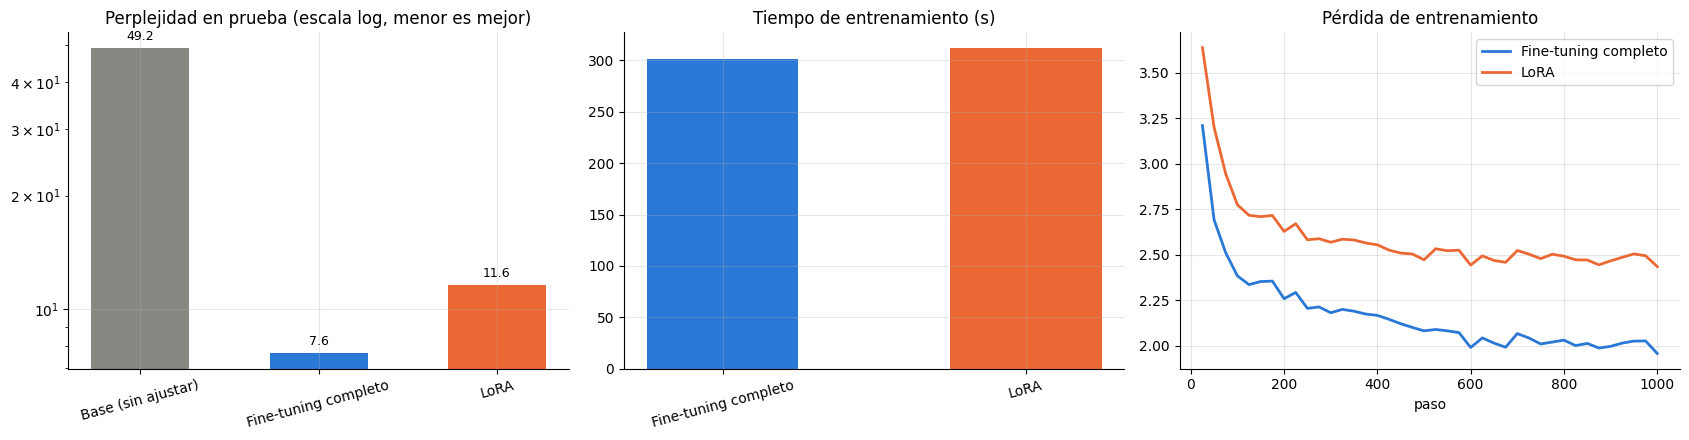

Mejor variante por perplejidad: Fine-tuning completo


In [ ]:
comparacion = pd.DataFrame([
    {'variante': 'Base (sin ajustar)', 'perplejidad': ppl_base, 'tiempo_seg': 0.0,
     'parametros_entrenables': 0, 'porcentaje_entrenable': 0.0},
] + [
    {'variante': r['nombre'], 'perplejidad': r['perplejidad'], 'tiempo_seg': r['tiempo'],
     'parametros_entrenables': r['parametros_entrenables'],
     'porcentaje_entrenable': 100 * r['parametros_entrenables'] / r['parametros_totales']}
    for r in resultados.values()
])
print(comparacion.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
colores = [COLORES[v] for v in comparacion['variante']]

axes[0].bar(comparacion['variante'], comparacion['perplejidad'], color=colores, width=0.55)
axes[0].set_yscale('log')
axes[0].set_title('Perplejidad en prueba (escala log, menor es mejor)')
for i, v in enumerate(comparacion['perplejidad']):
    axes[0].text(i, v * 1.05, f'{v:.1f}', ha='center', fontsize=9)

ajustados = comparacion.iloc[1:]
axes[1].bar(ajustados['variante'], ajustados['tiempo_seg'], color=colores[1:], width=0.5)
axes[1].set_title('Tiempo de entrenamiento (s)')

for r in resultados.values():
    h = r['historial']
    if len(h):
        axes[2].plot(h['step'], h['loss'], label=r['nombre'], color=COLORES[r['nombre']], linewidth=2)
axes[2].set_title('Pérdida de entrenamiento')
axes[2].set_xlabel('paso')
axes[2].legend()

for ax in axes[:2]:
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

mejor_nombre = min(resultados, key=lambda k: resultados[k]['perplejidad'])
print(f"Mejor variante por perplejidad: {mejor_nombre}")

### Análisis

- El fine-tuning bajó mucho la perplejidad: de 49,2 en el modelo base a 7,6 con el fine-tuning completo y a 11,6 con LoRA.
- LoRA queda por detrás del fine-tuning completo (pérdida de prueba de 2,45 frente a 2,03). Entrenando el 1,3 % de los parámetros recupera la mayor parte de la mejora, pero no toda.
- El tiempo fue casi igual: 301 segundos el completo y 312 LoRA. Los datos tienen que pasar por todas las capas en ida y vuelta aunque se entrenen pocos parámetros, y LoRA además agrega unas multiplicaciones extra. Con la GPU T4 la ventaja de LoRA está en la memoria y en el tamaño del modelo guardado, no en el tiempo.
- En las curvas de pérdida, LoRA empieza más alto y se queda cerca de 2,5 desde el paso 400 más o menos, mientras que el completo sigue bajando despacio hasta cerca de 2,0. Con más épocas o un rango mayor LoRA podría acercarse, pero no lo probamos.
- Para la generación usamos el fine-tuning completo porque tuvo la menor perplejidad.

## 7. Cómo evaluamos una receta generada

Para cada receta generada calculamos lo siguiente:

- Formato correcto: tiene "Ingredientes:" y después "Pasos:", al menos 2 ingredientes en forma de lista y pasos de al menos 5 palabras.
- Terminó: el modelo cerró la receta con el token de fin antes de llegar al límite de tokens.
- Cobertura: qué parte de los ingredientes listados se menciona en los pasos.
- Ingredientes no listados (en las tablas aparece como alucinacion): qué parte de los ingredientes que aparecen en los pasos no estaba en la lista. Sirve para ver si el modelo inventa ingredientes.
- Repetición: qué parte de las secuencias de 4 palabras se repite dentro de la misma receta. Sirve para detectar cuando el modelo entra en un bucle.
- Diversidad (distinct-2): cuántos pares de palabras distintos hay sobre el total, juntando todas las recetas de una estrategia.

La cobertura y los ingredientes no listados solo se calculan en las recetas con formato correcto. Todas las métricas se comparan con las mismas medidas sobre las recetas reales de prueba.

In [ ]:
def separar_secciones(texto):
    i = texto.find('Ingredientes:')
    j = texto.find('Pasos:', i + 1) if i >= 0 else -1
    if i < 0 or j < 0:
        return None
    bloque = texto[i + len('Ingredientes:'):j]
    lineas = [l.strip()[1:].strip() for l in bloque.split('\n') if l.strip().startswith('-')]
    pasos = texto[j + len('Pasos:'):].strip()
    return lineas, pasos


def repeticion(texto, n=4):
    w = texto.split()
    ngramas = [tuple(w[k:k + n]) for k in range(len(w) - n + 1)]
    return 1 - len(set(ngramas)) / len(ngramas) if ngramas else 0.0


def distinct_n(textos, n=2):
    ngramas = []
    for t in textos:
        w = t.split()
        ngramas += [tuple(w[k:k + n]) for k in range(len(w) - n + 1)]
    return len(set(ngramas)) / len(ngramas) if ngramas else 0.0


def evaluar_receta(texto):
    secciones = separar_secciones(texto)
    fila = {'formato_ok': False, 'cobertura': np.nan, 'alucinacion': np.nan,
            'repeticion': repeticion(texto), 'n_ingredientes': 0}
    if secciones is None:
        return fila
    lineas, pasos = secciones
    fila['n_ingredientes'] = len(lineas)
    if len(lineas) < 2 or len(pasos.split()) < 5:
        return fila
    fila['formato_ok'] = True
    listados = ingredientes_en(' '.join(lineas))
    en_pasos = ingredientes_en(pasos)
    fila['cobertura'] = cobertura(listados, en_pasos)
    fila['alucinacion'] = alucinacion(listados, en_pasos)
    return fila


def resumir(textos, terminados=None):
    filas = pd.DataFrame([evaluar_receta(t) for t in textos])
    return {
        'formato_ok_%': 100 * filas['formato_ok'].mean(),
        'terminó_%': 100 * np.mean(terminados) if terminados is not None else np.nan,
        'cobertura': filas['cobertura'].mean(),
        'alucinacion': filas['alucinacion'].mean(),
        'repeticion': filas['repeticion'].mean(),
        'distinct_2': distinct_n(textos, 2),
        'ingredientes_prom': filas['n_ingredientes'].mean(),
    }


# Referencia: las mismas métricas sobre las recetas reales del conjunto de prueba
prompts_df = test_df.head(CONFIG['n_prompts'])
PROMPTS = [prompt_receta(n) for n in prompts_df['Nombre']]
referencia = resumir(prompts_df['texto'].tolist(), [True] * len(prompts_df))
print("Recetas reales (referencia):")
print(pd.Series(referencia).round(3).to_string())

Recetas reales (referencia):
formato_ok_%         100.000
terminó_%            100.000
cobertura              0.623
alucinacion            0.614
repeticion             0.007
distinct_2             0.737
ingredientes_prom      7.700


## 8. Estrategias de decodificación

La guía compara greedy, muestreo y una mezcla de los dos (e-greedy). Aquí comparamos más estrategias, todas con el modelo de fine-tuning completo y con los mismos 30 nombres de recetas de prueba:

- Greedy: siempre escoge el token más probable.
- Greedy con bloqueo de 3-gramas: igual que greedy, pero no deja repetir ninguna secuencia de 3 tokens.
- Beam search con 4 haces: en cada paso guarda las 4 secuencias más probables y al final devuelve la mejor.
- e-greedy de la guía con eps de 0,5: la mitad de las veces toma el mejor token y la otra mitad muestrea.
- Muestreo puro: muestrea de toda la distribución.
- Top-k con k de 40: muestrea solo entre los 40 tokens más probables.
- Top-p con p de 0,9: muestrea entre los tokens más probables hasta sumar 0,9 de probabilidad. A diferencia de top-k, la cantidad de tokens cambia: son pocos cuando el modelo está seguro y muchos cuando duda.
- Top-p con penalización de repetición de 1,3: baja la probabilidad de los tokens que ya aparecieron.
- Contrastive search (Su et al., 2022): entre los tokens más probables escoge uno que sea probable pero también distinto de lo que ya se escribió.

También generamos con top-p usando el modelo base, para ver el efecto del fine-tuning.

Antes de correrlo pensamos que la penalización de repetición podía empeorar la coherencia, porque en una receta repetir el nombre de un ingrediente en los pasos es justamente lo que se busca.

In [ ]:
mejor_modelo = resultados[mejor_nombre]['model']
if hasattr(mejor_modelo, 'merge_and_unload'):
    # Si el mejor es LoRA, fusionamos el adaptador con los pesos para generar más rápido
    mejor_modelo = mejor_modelo.merge_and_unload()
mejor_modelo.eval()


def generar_eps_greedy(model, prompts, eps=0.5, max_new_tokens=None):
    # Política e-greedy de la guía, reescrita con caché de atención (past_key_values) para que sea más rápida
    max_new_tokens = max_new_tokens or CONFIG['max_new_tokens']
    textos, terminados = [], []
    for p in prompts:
        ids = tokenizer(p, return_tensors='pt')['input_ids'].to(DEVICE)
        generados, past, siguiente, termino = [], None, ids, False
        with torch.no_grad():
            for _ in range(max_new_tokens):
                out = model(input_ids=siguiente, past_key_values=past, use_cache=True)
                past = out.past_key_values
                probs = torch.softmax(out.logits[0, -1, :].float(), dim=-1)
                if np.random.random() < eps:
                    token = torch.argmax(probs).view(1, 1)
                else:
                    token = torch.multinomial(probs, 1).view(1, 1)
                if token.item() == EOS_ID:
                    termino = True
                    break
                generados.append(token.item())
                siguiente = token
        textos.append(p + tokenizer.decode(generados))
        terminados.append(termino)
    return textos, terminados


def generar_contrastive(model, prompts, penalty_alpha=0.6, top_k=4):
    # En versiones recientes de transformers, contrastive search se movió a un repositorio del Hub
    # (custom_generate). Probamos ambas formas; si ninguna funciona, se omite la estrategia.
    from packaging import version
    extra = dict(penalty_alpha=penalty_alpha, top_k=top_k, do_sample=False)
    if version.parse(transformers.__version__) >= version.parse('4.56.0'):
        extra.update(custom_generate='transformers-community/contrastive-search', trust_remote_code=True)
    try:
        return generar(model, prompts, batch_size=1, **extra)
    except Exception as e:
        print(f"Contrastive search no disponible en esta versión ({type(e).__name__}: {str(e)[:120]}). Se omite.")
        return None


ESTRATEGIAS = {
    'Greedy': dict(do_sample=False),
    'Greedy + bloqueo 3-gramas': dict(do_sample=False, no_repeat_ngram_size=3),
    'Beam search (4)': dict(do_sample=False, num_beams=4, early_stopping=True),
    'Muestreo puro (T=1)': dict(do_sample=True, temperature=1.0, top_k=0, top_p=1.0),
    'Top-k (k=40)': dict(do_sample=True, temperature=1.0, top_k=40, top_p=1.0),
    'Top-p (p=0.9)': dict(do_sample=True, temperature=1.0, top_k=0, top_p=0.9),
    'Top-p + penalización 1.3': dict(do_sample=True, temperature=1.0, top_k=0, top_p=0.9, repetition_penalty=1.3),
}

generaciones, filas = {}, []

def registrar(nombre, salida, inicio):
    if salida is None:
        return
    textos, terminados = salida
    generaciones[nombre] = textos
    fila = {'estrategia': nombre, **resumir(textos, terminados), 'tiempo_seg': time.time() - inicio}
    filas.append(fila)
    print(f"{nombre:<28} formato {fila['formato_ok_%']:5.1f}% | cobertura {fila['cobertura']:.2f} | "
          f"alucinación {fila['alucinacion']:.2f} | distinct-2 {fila['distinct_2']:.2f} | {fila['tiempo_seg']:.0f}s")

for nombre, params in ESTRATEGIAS.items():
    set_seed(SEED)
    inicio = time.time()
    registrar(nombre, generar(mejor_modelo, PROMPTS, **params), inicio)

set_seed(SEED)
inicio = time.time()
registrar('e-greedy (guía, eps=0.5)', generar_eps_greedy(mejor_modelo, PROMPTS, eps=0.5), inicio)

set_seed(SEED)
inicio = time.time()
registrar('Contrastive search', generar_contrastive(mejor_modelo, PROMPTS), inicio)

set_seed(SEED)
inicio = time.time()
registrar('Modelo base + top-p', generar(modelo_base, PROMPTS, **ESTRATEGIAS['Top-p (p=0.9)']), inicio)

tabla_decod = pd.DataFrame(filas).set_index('estrategia')
tabla_decod.loc['Recetas reales (referencia)'] = pd.Series({**referencia, 'tiempo_seg': np.nan})
tabla_decod.round(3)

Greedy                       formato  96.7% | cobertura 0.76 | alucinación 0.70 | distinct-2 0.15 | 10s
Greedy + bloqueo 3-gramas    formato 100.0% | cobertura 0.83 | alucinación 0.89 | distinct-2 0.51 | 10s
Beam search (4)              formato  90.0% | cobertura 0.87 | alucinación 0.64 | distinct-2 0.13 | 15s
Muestreo puro (T=1)          formato 100.0% | cobertura 0.36 | alucinación 0.87 | distinct-2 0.81 | 10s
Top-k (k=40)                 formato  93.3% | cobertura 0.56 | alucinación 0.74 | distinct-2 0.66 | 10s
Top-p (p=0.9)                formato  96.7% | cobertura 0.54 | alucinación 0.74 | distinct-2 0.69 | 10s
Top-p + penalización 1.3     formato  96.7% | cobertura 0.34 | alucinación 0.89 | distinct-2 0.83 | 10s
e-greedy (guía, eps=0.5)     formato  96.7% | cobertura 0.58 | alucinación 0.71 | distinct-2 0.53 | 111s


generate.py:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/transformers-community/contrastive-search:
- custom_generate/generate.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Contrastive search           formato  93.3% | cobertura 0.68 | alucinación 0.73 | distinct-2 0.46 | 159s
Modelo base + top-p          formato   0.0% | cobertura nan | alucinación nan | distinct-2 0.81 | 10s


,formato_ok_%,terminó_%,cobertura,alucinacion,repeticion,distinct_2,ingredientes_prom,tiempo_seg
estrategia,,,,,,,,
Greedy,96.667,0.000,0.761,0.697,0.623,0.145,16.167,9.532
Greedy + bloqueo 3-gramas,100.000,3.333,0.833,0.891,0.001,0.515,2.667,9.525
Beam search (4),90.000,10.000,0.873,0.644,0.483,0.128,6.000,15.090
Muestreo puro (T=1),100.000,43.333,0.362,0.867,0.007,0.808,7.133,9.504
Top-k (k=40),93.333,53.333,0.555,0.740,0.017,0.656,7.867,9.910
Top-p (p=0.9),96.667,60.000,0.538,0.738,0.012,0.688,7.267,10.204
Top-p + penalización 1.3,96.667,73.333,0.335,0.890,0.002,0.831,3.267,10.445
"e-greedy (guía, eps=0.5)",96.667,53.333,0.577,0.714,0.081,0.528,8.267,110.515
Contrastive search,93.333,26.667,0.677,0.732,0.052,0.462,3.833,159.424


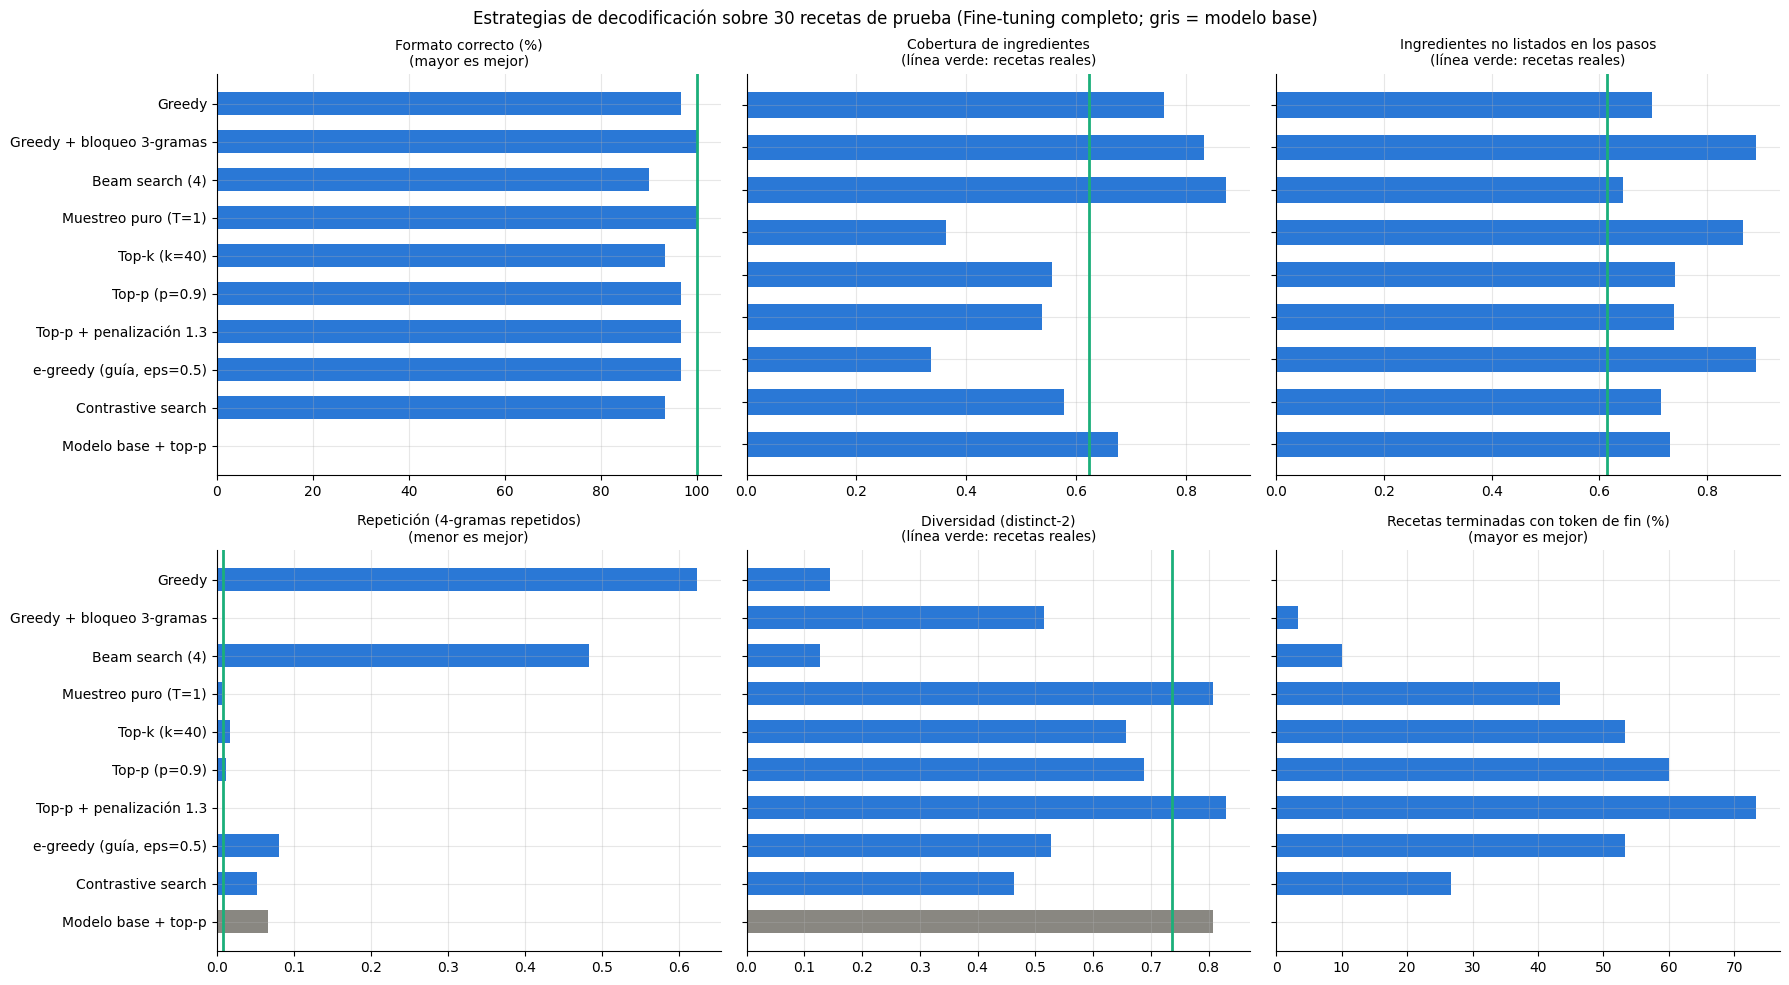

In [ ]:
orden = [e for e in tabla_decod.index if e != 'Recetas reales (referencia)']
ref = tabla_decod.loc['Recetas reales (referencia)']

metricas = [
    ('formato_ok_%', 'Formato correcto (%)', 'mayor es mejor'),
    ('cobertura', 'Cobertura de ingredientes', 'línea verde: recetas reales'),
    ('alucinacion', 'Ingredientes no listados en los pasos', 'línea verde: recetas reales'),
    ('repeticion', 'Repetición (4-gramas repetidos)', 'menor es mejor'),
    ('distinct_2', 'Diversidad (distinct-2)', 'línea verde: recetas reales'),
    ('terminó_%', 'Recetas terminadas con token de fin (%)', 'mayor es mejor'),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for k, (ax, (col, titulo, nota)) in enumerate(zip(axes.ravel(), metricas)):
    valores = tabla_decod.loc[orden, col]
    colores = ['#898781' if e.startswith('Modelo base') else '#2a78d6' for e in orden]
    ax.barh(orden, valores, color=colores, height=0.6)
    if col != 'terminó_%' and not np.isnan(ref[col]):
        ax.axvline(ref[col], color='#1baf7a', linewidth=2)
    ax.set_title(f'{titulo}\n({nota})', fontsize=10)
    ax.invert_yaxis()
    if k % 3:
        ax.tick_params(labelleft=False)
plt.suptitle(f'Estrategias de decodificación sobre {len(PROMPTS)} recetas de prueba ({mejor_nombre}; gris = modelo base)')
plt.tight_layout()
plt.show()

In [ ]:
# Misma receta con cada estrategia, para leer las diferencias
i = 0
print(f"PROMPT: {PROMPTS[i]!r}\nRECETA REAL:\n{prompts_df['texto'].iloc[i][:500]}\n")
for nombre, textos in generaciones.items():
    print('=' * 100)
    print(f'[{nombre}]')
    print(textos[i][:700])

PROMPT: 'Receta: lomo asado\nIngredientes:\n'
RECETA REAL:
Receta: lomo asado
Ingredientes:
- ['1 kg de cinta de lomo al ajillo'
- '1/2 kg de zanahorias'
- '2 pimientos verdes'
- '1 pimiento rojo'
- '2 tomates maduros'
- '2 cebollas'
- 'harina'
- 'aceite de oliva'
- 'ajo'
- 'perejil'
- 'vino blanco'
- 'sal']
Pasos:
['1 Salamos la cinta de lomo y la pasamos por harina,en una sarten con aceite freimos por todas las caras la cinta,cuando este dorado retiramos y reservamos.', '2 Cortamos todas las verduras en dados y pochamos en el aceite del lomo,añadimos 

[Greedy]
Receta: lomo asado
Ingredientes:
- ['1 kilogramo de lomo'
- '1 cebolla'
- '1/2 kilogramo de cebolla'
- '1/2 kilogramo de tomate'
- '1/2 kilogramo de pimentón'
- '1/2 kilogramo de pimentón'
- '1/2 kilogramo de pimentón'
- '1/2 kilogramo de tomate'
- '1/2 kilogramo de pimentón'
- '1/2 kilogramo de tomate'
- '1/2 kilogramo de pimentón'
- '1/2 kilogramo de pimentón'
- '1/2 kilogramo de tomate'
- '1/2 kilogramo de pimentón'
- '1/2 

### Análisis

Hay que leer los números junto con las recetas, porque algunas métricas se ven bien por razones equivocadas.

- Modelo base: 0 % de formato correcto. Sin fine-tuning no genera recetas.
- Greedy y beam search tienen buen formato y la cobertura más alta (0,76 y 0,87), pero es porque repiten. La repetición es de 0,62 en greedy y 0,48 en beam search, contra 0,007 en las recetas reales, y la diversidad es muy baja (0,15 y 0,13). En el ejemplo del lomo asado, greedy repite "1/2 kilogramo de pimentón" muchas veces y beam search repite "la sal y la pimienta" en cada paso. Greedy no terminó ninguna receta.
- El bloqueo de 3-gramas quita la repetición, pero corta la lista de ingredientes: el promedio baja a 2,7 ingredientes. Cada línea de la lista empieza con la misma secuencia de tokens y el bloqueo no deja repetirla. Además tiene la cifra más alta de ingredientes no listados (0,89).
- El muestreo puro es el más variado (0,81 de diversidad, más que las recetas reales) pero el menos coherente: cobertura de 0,36 y 0,87 de ingredientes no listados. Las recetas tienen frases sin sentido.
- Top-k y top-p quedan en un punto intermedio. Top-p tiene una diversidad de 0,69, cerca de la de las recetas reales (0,74), repetición de 0,012 y 60 % de recetas terminadas. Fue la estrategia más equilibrada.
- Se confirmó lo que pensábamos de la penalización de repetición: tiene la cobertura más baja (0,34), 0,89 de ingredientes no listados y listas de solo 3,3 ingredientes. Al castigar las palabras que ya aparecieron, el modelo evita nombrar en los pasos los ingredientes de la lista.
- Contrastive search tiene buena cobertura (0,68) con poca repetición (0,05), pero listas cortas (3,8 ingredientes) y fue la más lenta (159 segundos contra unos 10 de las estrategias de Hugging Face). El e-greedy de la guía queda parecido a top-k y también es lento (111 segundos) porque genera token por token en un ciclo de Python.
- Pocas recetas terminan con el token de fin. Al leer los ejemplos vimos por qué: muchas recetas generadas tienen corchetes y comillas, como "['1 kilogramo de lomo'", y los pasos salen numerados dentro de una lista. Es el formato de la parte del dataset que guarda las listas como texto, que mencionamos en el EDA. Cuando el modelo cierra esa lista sigue escribiendo fragmentos sueltos como "Queso rallado']" en lugar de terminar. Es un problema de los datos más que de la estrategia, y con una mejor limpieza debería mejorar.
- Para el demo usamos top-p.

## 9. Temperatura

La temperatura cambia qué tan concentradas están las probabilidades antes de muestrear. Con una temperatura baja el modelo casi siempre escoge los tokens más probables y se parece a greedy. Con una temperatura alta los tokens poco probables tienen más oportunidad de salir. La guía usa una temperatura fija; aquí probamos varios valores para ver cómo cambian la diversidad y la coherencia.

T=0.3: formato 100% | distinct-2 0.22 | alucinación 0.63
T=0.6: formato 100% | distinct-2 0.45 | alucinación 0.60
T=0.9: formato 97% | distinct-2 0.72 | alucinación 0.76
T=1.2: formato 83% | distinct-2 0.94 | alucinación 0.95
T=1.5: formato 7% | distinct-2 0.99 | alucinación 1.00


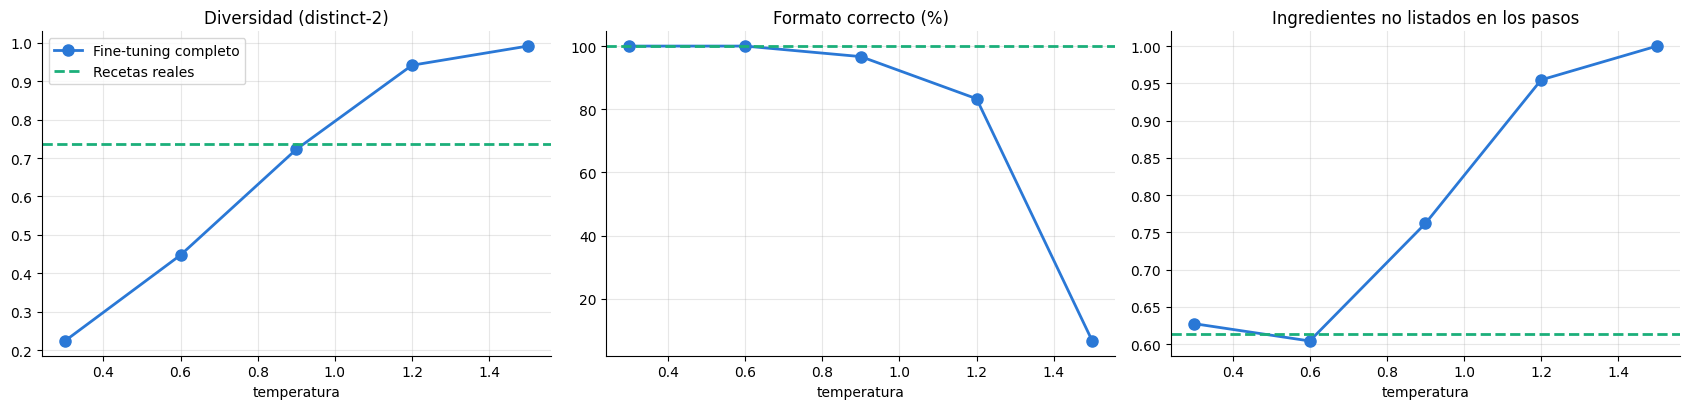

In [ ]:
TEMPERATURAS = [0.3, 0.6, 0.9, 1.2, 1.5]
filas_t = []
for T in TEMPERATURAS:
    set_seed(SEED)
    textos, terminados = generar(mejor_modelo, PROMPTS, do_sample=True, temperature=T, top_k=0, top_p=1.0)
    filas_t.append({'temperatura': T, **resumir(textos, terminados)})
    print(f"T={T}: formato {filas_t[-1]['formato_ok_%']:.0f}% | distinct-2 {filas_t[-1]['distinct_2']:.2f} | "
          f"alucinación {filas_t[-1]['alucinacion']:.2f}")
tabla_t = pd.DataFrame(filas_t)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for ax, (col, titulo) in zip(axes, [('distinct_2', 'Diversidad (distinct-2)'),
                                    ('formato_ok_%', 'Formato correcto (%)'),
                                    ('alucinacion', 'Ingredientes no listados en los pasos')]):
    ax.plot(tabla_t['temperatura'], tabla_t[col], marker='o', markersize=8, linewidth=2, color='#2a78d6',
            label=mejor_nombre)
    ax.axhline(referencia[col], color='#1baf7a', linewidth=2, linestyle='--', label='Recetas reales')
    ax.set_xlabel('temperatura')
    ax.set_title(titulo)
axes[0].legend()
plt.tight_layout()
plt.show()

### Análisis

- Con 0,3 el formato es perfecto pero la diversidad es muy baja (0,22) y el texto se repite.
- Con 0,6 los ingredientes no listados bajan a 0,60, el valor más cercano a las recetas reales (0,61), pero la diversidad (0,45) todavía está lejos de la real (0,74).
- Con 0,9 la diversidad (0,72) es casi igual a la real, pero los ingredientes no listados suben a 0,76.
- Desde 1,2 el formato se empieza a perder (83 %) y con 1,5 casi desaparece (7 %), con texto prácticamente al azar.

No hay una temperatura que se parezca a las recetas reales en todo. El mejor rango está entre 0,6 y 0,9, según si se prefiere coherencia o variedad. Top-p con p de 0,9 dio resultados parecidos a la temperatura de 0,9, así que es una opción más sencilla de ajustar.

## 10. Demo: una receta a partir de ingredientes

Como en el formato los ingredientes van antes que los pasos, podemos darle al modelo el nombre de un plato y algunos ingredientes, y dejar que complete el resto. Después revisamos si usó en los pasos los ingredientes que le dimos.

Probamos con platos colombianos. Como en el EDA vimos que solo el 1,2 % de las recetas son de Colombia, esto también sirve para ver qué pasa con platos poco representados en los datos.

In [ ]:
ESTRATEGIA_DEMO = ESTRATEGIAS['Top-p (p=0.9)']   # cambiar por la mejor estrategia según la sección 8


def receta_desde_ingredientes(ingredientes, nombre='', semilla=SEED, **params):
    params = params or ESTRATEGIA_DEMO
    prompt = f"Receta: {nombre}\nIngredientes:\n" + ''.join(f'- {i}\n' for i in ingredientes)
    set_seed(semilla)
    (texto,), _ = generar(mejor_modelo, [prompt], batch_size=1, **params)
    print(texto)
    secciones = separar_secciones(texto)
    print('\n' + '-' * 80)
    if secciones is None:
        print('El modelo no llegó a escribir la sección de pasos.')
        return texto
    _, pasos = secciones
    dados = {i: bool(ingredientes_en(i) & ingredientes_en(pasos)) for i in ingredientes}
    usados = sum(dados.values())
    print(f"Ingredientes dados que se usan en los pasos: {usados}/{len(ingredientes)}")
    for ing, ok in dados.items():
        print(f"   {'sí' if ok else 'no'}  {ing}")
    return texto


_ = receta_desde_ingredientes(['2 tazas de harina de maíz precocida', '1 taza de queso costeño rallado',
                               '1 cucharada de mantequilla'], nombre='Arepas de queso')

Receta: Arepas de queso
Ingredientes:
- 2 tazas de harina de maíz precocida
- 1 taza de queso costeño rallado
- 1 cucharada de mantequilla
- 2 dientes de ajo finamente picado
- ½ taza de leche evaporada
- 1 cucharada de pimienta amarga
- 1 cucharada de jengibre escurrido
- 2 tazas de harina de trigo
- Aceite de oliva
- 4 huevos
- Sal
- Pimienta
Pasos:
Cocinar en una olla la harina de maíz y el ajo finamente picado, adicionando 1 cucharada de mantequilla, 2 huevos, 1 cucharada de leche evaporada y sal al gusto. Salpimentar hasta que el agua hierve y luego adicionarla. Escurrir. Dorar el queso por ambos lados. Reservar para un postre o para facilitar su cocción, tallarines en lonchas finas y voltear. Adornar con azúcar de caña y tomate. Secar. Agregar las arepas, remojar en la leche. Calentar el horno a 200ºC por 45 minutos. Añadir el postre fresco y en el fondo repetir la operación. Verter el jugo sobre las arepas, agregarle más azúcar de caña y aceite de oliva. Escurrir. Sazonar con sa

In [ ]:
_ = receta_desde_ingredientes(['4 plátanos verdes', 'aceite para freír', 'sal al gusto'], nombre='Patacones')

Receta: Patacones
Ingredientes:
- 4 plátanos verdes
- aceite para freír
- sal al gusto
- 2 mitades de mango rojo y un bote de aceite para freír
- ¾ de taza de café amargo
- 2 chuletas de cerdo
Pasos:
Colocarlos sobre la mesa y freír hasta que estén muy tiernos. Agregar un poco de jugo y sal y agregarles el jugo de las chuletas de cerdo para que las chuletas no se peguen. Acompañar con las verduras con sal y pimienta. Retirar del fuego y meter en una olla con agua hirviendo. Cocinar hasta que las hojas estén tiernas. Mezclar con los plátanos. Escurrir. Dorar en aceite de oliva. Añadir las patas de los plátanos a la olla y las chuletas de cerdo. Cubrir con los restantes plátanos. Jugar. Al finalizar la preparación a fuego lento, espolvorear un poco de sal y añadir el resto de los plátanos verdes y hervir durante 45 minutos o hasta que se integren las hojas. Exprimir en forma de pizza. Vierte los plátanos a la plancha, junto con las verduras a mano. Calorías (en miligramos)caro grasoquis 

In [ ]:
_ = receta_desde_ingredientes(['1 pechuga de pollo', '2 papas', '1 mazorca', '1 manojo de guascas'],
                              nombre='Ajiaco')

Receta: Ajiaco
Ingredientes:
- 1 pechuga de pollo
- 2 papas
- 1 mazorca
- 1 manojo de guascas
- 2 dientes de ajo
- ½ cebolla
- 2 gotas de azúcar
- ¼ de taza de agua
- 2 chuletas de pollo
- ½ zanahoria
- ¼ de taza de leche
Pasos:
Colocar la guasca en un frasco de vidrio. Acompañar con una rebanada de pan para apagar el fuego y cocer con él las patatas, cocinar hasta que las cebollas sean espesas. Incorporar a la olla las papas, cada una de ellas cocida sobre su propio lado hasta que estén solidificadas y luego retirar. Se puede combinar con salsa de tomate y pollo y por supuesto agregue el ajiaco para evitar que se salga. Sirva con marisco o con un caldo caliente como flan. Masajear con agua con picante para ser preciso y por último incorporarlo en la olla o remojarlo en aceite. Mejores tiempos de venta:Gran parte de la demanda depende de donde se sirve, así que no olvide repetir la receta de la anterior. Las últimas recetas están llenas de ingredientes, pero si desea más recetas fresca

In [ ]:
# Pruebe con sus propios ingredientes (y sin nombre de plato, para que el modelo lo invente)
_ = receta_desde_ingredientes(['3 huevos', '1 tomate', '1/2 cebolla', 'sal al gusto'])

Receta: 
Ingredientes:
- 3 huevos
- 1 tomate
- 1/2 cebolla
- sal al gusto
- 2 dientes de ajo molidos
- ½ punto 2 gotas de azúcarρι, lón pitillos- 1 cucharadita de aguardiente
Pasos:
Mezcla el tomate, la cebolla y el ajo en un colador. Patea ligeramente el tomate en cuadros y añade los huevos. Agrega la lón pitillos y cuando esté lista agrege los huevos por encima, revuelve hasta que las verduras estén blandas. En una cacerola junto con las habas cada una agrega la cebolla troceada hasta que quede como un puré. Coloca en una bandeja que contenga hojas de menta rallada y sírvela acompañado de otra taza de azúcar para darle sabor. sirve fría ya que su corazón necesita de todo. paladinízate.Irónicamente, según el experimento de Búzzard, los hombres hacen cualquier cosa para alcanzar una estrella y vivir.Las Vegas, Estados Unidos – Una gran noche y la vida fabulosa donde gastar un poco de dinero y disfrutar de la vida americana.martes a domingo a las 11:30 pmdivertido a las 7:00 pmYa puede

### Análisis

- En las arepas de queso usó los 3 ingredientes dados, pero agregó cosas que no van en unas arepas, como jengibre, harina de trigo y azúcar de caña, y al final dice que se pueden usar "para helados".
- En los patacones también usó los 3 ingredientes, pero agregó mango, café y chuletas de cerdo, y hacia el final el texto pierde sentido.
- En el ajiaco usó el pollo y las papas, pero no la mazorca ni las guascas, que son ingredientes muy colombianos y casi no aparecen en el dataset. Además escribe "patatas", que es como se dice en España, y después se desvía a hablar de otras recetas.
- Sin nombre de plato, con huevos, tomate y cebolla, empezó con algo parecido a unos huevos revueltos, pero después pasó a hablar de Las Vegas y de fiestas con piñatas.

En los cuatro casos el modelo usa casi todos los ingredientes que le damos, pero los platos colombianos no salen reconocibles: se parecen más a recetas españolas o mexicanas, que es lo que más hay en los datos. Ninguna de las cuatro recetas terminó antes del límite de tokens, y cuando el texto se alarga se sale del tema. También notamos que, como le dimos los ingredientes sin corchetes, en el demo los pasos salieron como texto normal y no como lista.

## 11. Conclusiones

- El fine-tuning es necesario. El modelo base no genera recetas (0 % de formato correcto y perplejidad de 49,2). Con 4000 recetas y 2 épocas el modelo aprendió el formato: la perplejidad bajó a 7,6 y más del 90 % de las recetas generadas tienen formato correcto con casi todas las estrategias.
- LoRA, entrenando el 1,3 % de los parámetros, bajó la perplejidad a 11,6. Recupera la mayor parte de la mejora, pero queda por detrás del fine-tuning completo y en nuestro caso no ahorró tiempo. Sirve cuando importan la memoria o guardar varios modelos, no para entrenar más rápido.
- La estrategia de decodificación cambia mucho el resultado. Greedy y beam search parecen coherentes en las métricas, pero se repiten. El muestreo puro es variado pero incoherente. Top-p fue el mejor equilibrio entre formato, coherencia, diversidad y repetición.
- La penalización de repetición y el bloqueo de n-gramas, que normalmente se usan para evitar bucles, empeoraron las recetas: el modelo dejó de nombrar los ingredientes en los pasos e hizo listas más cortas. En un texto con estructura, algo de repetición es necesaria.
- Con la temperatura no hay un valor que sirva para todo. Entre 0,6 y 0,9 está el mejor equilibrio, y por encima de 1,2 el formato se pierde.
- Medir con números ayudó, pero no fue suficiente. La cobertura alta de greedy y beam search venía de la repetición, y el problema de los corchetes solo lo vimos al leer las recetas. Hay que mirar las métricas y los textos juntos.

Limitaciones:

- Una parte del dataset guarda las listas como texto con corchetes y nuestra limpieza no lo trató. El modelo aprendió ese formato y por eso muchas recetas no terminan bien.
- El dataset tiene sobre todo recetas de España y México, y eso se notó en los platos colombianos del demo.
- Solo entrenamos con recetas de hasta 384 tokens, es decir, con la mitad más corta del dataset.
- El léxico de ingredientes es aproximado y deja pasar palabras que no son ingredientes. Eso explica en parte que incluso las recetas reales tengan 0,61 de ingredientes no listados.
- Evaluamos la generación con 30 recetas y una sola semilla, así que diferencias pequeñas entre estrategias no son concluyentes.

## Referencias

- Dataset somosnlp/RecetasDeLaAbuela: https://huggingface.co/datasets/somosnlp/RecetasDeLaAbuela
- Modelo mrm8488/spanish-gpt2: https://huggingface.co/mrm8488/spanish-gpt2
- Radford et al. (2018). Improving Language Understanding by Generative Pre-Training.
- Hu et al. (2021). LoRA: Low-Rank Adaptation of Large Language Models. https://arxiv.org/abs/2106.09685
- Holtzman et al. (2020). The Curious Case of Neural Text Degeneration (top-p). https://arxiv.org/abs/1904.09751
- Su et al. (2022). A Contrastive Framework for Neural Text Generation. https://arxiv.org/abs/2202.06417
- Li et al. (2016). A Diversity-Promoting Objective Function for Neural Conversation Models (distinct-n). https://arxiv.org/abs/1510.03055
- Notebook guía del curso: 1-text-generation.ipynb (sesión 4).